<a href="https://colab.research.google.com/github/denise-accuni/mulheres/blob/main/mulheres_computacao_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 👩‍💻♥ Mulheres na Computação — Mineração de Dados

> **Dataset:** `mulheres_computacaov7.csv` — 1.351 registros coletados via Wikipedia & Wikidata API  
> **Disciplina:** Ciência de Dados —👩‍💻♥ Mulheres na Computação — Mineração de Dados
$0 UFRRJ   
> **Alunos:** DENISE MORAES DO NASCIMENTO VIEIRA e CESAR PINTO DOS SANTOS   
> **Professor:** LEANDRO GUIMARAES MARQUES ALVIM   
> **Tema:** Humanidades Digitais - Representatividade Feminina na TI

---

## 📋 Roteiro do Notebook

| # | Seção | Técnicas |
|---|-------|----------|
| 1 | Instalação e Importações | pip, imports |
| 2 | Carregamento e Inspeção | pandas, info, describe |
| 3 | Limpeza e Pré-processamento | fillna, strip, encode |
| 4 | EDA — Análise Exploratória | histogramas, barras, pizza, heatmap |
| 5 | Análise de Texto / NLP | frequência, word cloud, bigramas, trigramas |
| 6 | Mapa de Calor de Correlações | Pearson, seaborn heatmap |
| 7 | Clusterização (K-Means) | PCA, Elbow, silhueta |
| 8 | Mapa de Aproximação (t-SNE) | redução de dimensionalidade |
| 9 | Classificação (Random Forest) | treino/teste, matriz de confusão, ROC |
|10 | Conclusões | síntese dos achados |

---
## 1️⃣ Instalação de Dependências e Importações

In [1]:
# ─────────────────────────────────────────────────────────────
# INSTALAÇÃO DE BIBLIOTECAS EXTRAS
# No Google Colab a maioria já vem instalada, mas garantimos
# que wordcloud e plotly estejam disponíveis.
# ─────────────────────────────────────────────────────────────
!pip install wordcloud plotly -q

In [2]:
# ─────────────────────────────────────────────────────────────
# IMPORTAÇÕES
# Organizamos as importações por categoria para facilitar
# a leitura e manutenção do código.
# ─────────────────────────────────────────────────────────────

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização estática
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# Visualização interativa
import plotly.express as px
import plotly.graph_objects as go

# Processamento de linguagem natural (NLP)
import re
from collections import Counter
from nltk.util import ngrams
from wordcloud import WordCloud, STOPWORDS
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
from nltk.corpus import stopwords

# Machine Learning
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, RocCurveDisplay, silhouette_score
)

# Configurações visuais globais
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

# Paleta de cores temática (tons de roxo/berry)
PALETTE = ['#7B2D5E', '#B86A96', '#D4875A', '#5B8FA8', '#2D7A4F', '#9B5A2D', '#6B5EA8']

print('✅ Todas as bibliotecas importadas com sucesso!')

✅ Todas as bibliotecas importadas com sucesso!


---
## 2️⃣ Carregamento e Inspeção Inicial dos Dados

> **Conceito de CD:** Antes de qualquer análise, precisamos entender a *estrutura* do dataset —  
> quantas linhas, quantas colunas, quais tipos de dados e onde há valores ausentes.

In [7]:
# ─────────────────────────────────────────────────────────────
# CARREGAMENTO DO ARQUIVO
# O encoding='utf-8-sig' trata o BOM (Byte Order Mark) que
# alguns editores adicionam ao início de arquivos UTF-8.
# ─────────────────────────────────────────────────────────────
df = pd.read_csv('/content/sample_data/mulheres_computacaov7.csv', encoding='utf-8-sig')

print(f'📐 Dimensões do dataset: {df.shape[0]} linhas × {df.shape[1]} colunas')
print()
print('📋 Primeiras 3 linhas:')
df.head(3)

📐 Dimensões do dataset: 1351 linhas × 22 colunas

📋 Primeiras 3 linhas:


,Nome completo,Wikidata QID,Wikipedia URL,Wikidata URL,Continente,País,Ano de nascimento,Período temporal,Década de nascimento,Data de nascimento bruta,...,Setor de atuação (categoria),Instituição/Organização de vínculo,Local de nascimento/residência,Principais obras/contribuições (máx. 3 linhas),Imagem (URL se disponível),Fonte da coleta,Idioma da Wikipedia,Data/hora da coleta,Qualidade da evidência (Alto/Médio/Baixo),Licença/proveniência
0,Sihem Amer-Yahia,Q93377981,https://en.wikipedia.org/wiki/Sihem_Amer-Yahia,https://www.wikidata.org/wiki/Q93377981,África,Algeria,1972.0,1950–1999,1970s,1972-00-00T00:00:00Z,...,computer scientist; researcher,NaN,Algiers,NaN,https://upload.wikimedia.org/wikipedia/commons...,Women computer scientists,en,2026-05-21T21:23:44,Alto,CC BY-SA 4.0 / conforme licenças Wikipedia e W...
1,Fatmah Baothman,Q101714000,https://en.wikipedia.org/wiki/Fatmah_Baothman,https://www.wikidata.org/wiki/Q101714000,Ásia,Saudi Arabia,NaN,Sem ano de nascimento informado,NaN,NaN,...,computer scientist; researcher,NaN,Saudi Arabia,NaN,NaN,Women computer scientists,en,2026-05-21T21:23:44,Alto,CC BY-SA 4.0 / conforme licenças Wikipedia e W...
2,Marine Carpuat,Q93953866,https://en.wikipedia.org/wiki/Marine_Carpuat,https://www.wikidata.org/wiki/Q93953866,Global,NaN,NaN,Sem ano de nascimento informado,NaN,NaN,...,computational linguist,NaN,NaN,NaN,NaN,Women computer scientists,en,2026-05-21T21:23:44,Médio,CC BY-SA 4.0 / conforme licenças Wikipedia e W...


In [8]:
# ─────────────────────────────────────────────────────────────
# TIPOS E VALORES AUSENTES
# df.info() mostra o tipo de cada coluna e quantos valores
# não-nulos existem — essencial para planejar a limpeza.
# ─────────────────────────────────────────────────────────────
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1351 entries, 0 to 1350
Data columns (total 22 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Nome completo                                   1351 non-null   object 
 1   Wikidata QID                                    1351 non-null   object 
 2   Wikipedia URL                                   1351 non-null   object 
 3   Wikidata URL                                    1351 non-null   object 
 4   Continente                                      1351 non-null   object 
 5   País                                            785 non-null    object 
 6   Ano de nascimento                               746 non-null    float64
 7   Período temporal                                1351 non-null   object 
 8   Década de nascimento                            746 non-null    object 
 9   Data de nascimento bruta                 

/tmp/ipykernel_14989/2735852878.py:16: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


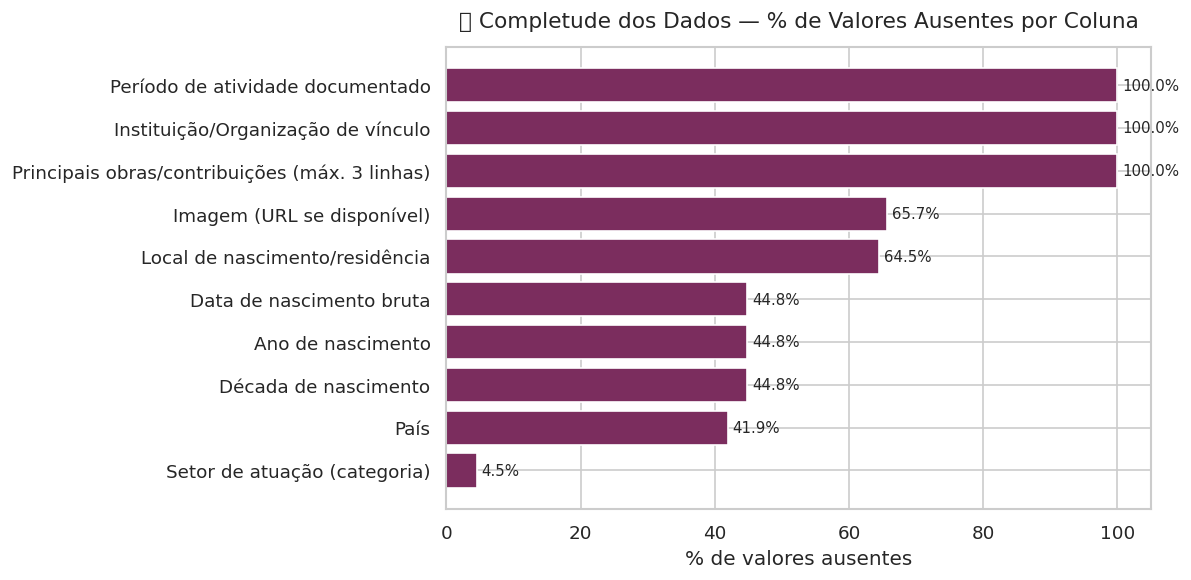

                                        Coluna  % Ausente
              Período de atividade documentado      100.0
            Instituição/Organização de vínculo      100.0
Principais obras/contribuições (máx. 3 linhas)      100.0
                    Imagem (URL se disponível)       65.7
                Local de nascimento/residência       64.5
                      Data de nascimento bruta       44.8
                             Ano de nascimento       44.8
                          Década de nascimento       44.8
                                          País       41.9
                  Setor de atuação (categoria)        4.5


In [9]:
# ─────────────────────────────────────────────────────────────
# ANÁLISE DE VALORES AUSENTES
# Calculamos a % de nulos por coluna e visualizamos
# em ordem decrescente para priorizar o tratamento.
# ─────────────────────────────────────────────────────────────
nulos = df.isnull().mean().mul(100).round(1).sort_values(ascending=False)
nulos_df = nulos[nulos > 0].reset_index()
nulos_df.columns = ['Coluna', '% Ausente']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(nulos_df['Coluna'], nulos_df['% Ausente'], color=PALETTE[0])
ax.bar_label(bars, fmt='%.1f%%', padding=3, fontsize=9)
ax.set_xlabel('% de valores ausentes')
ax.set_title('🔍 Completude dos Dados — % de Valores Ausentes por Coluna', fontsize=13, pad=12)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(nulos_df.to_string(index=False))

In [10]:
# ─────────────────────────────────────────────────────────────
# ESTATÍSTICAS DESCRITIVAS — COLUNA NUMÉRICA
# describe() fornece contagem, média, desvio padrão,
# mínimo, quartis e máximo para colunas numéricas.
# ─────────────────────────────────────────────────────────────
df[['Ano de nascimento']].describe().round(1)

,Ano de nascimento
count,746.0
mean,1959.7
std,20.8
min,1898.0
25%,1949.0
50%,1961.0
75%,1972.8
max,2000.0


---
## 3️⃣ Limpeza e Pré-processamento

> **Conceito de CD:** *Data Cleaning* é a etapa de padronizar, corrigir e preparar os dados  
> para análise. Dados sujos levam a conclusões erradas — "garbage in, garbage out".

In [12]:
# ─────────────────────────────────────────────────────────────
# LIMPEZA GERAL
# 1. Removemos espaços extras nos campos de texto
# 2. Preenchemos nulos em colunas categóricas com 'Desconhecido'
# 3. Convertemos o ano de nascimento para inteiro onde disponível
# ─────────────────────────────────────────────────────────────

# Colunas de texto que vamos usar
COLS_TEXTO = [
    'Continente', 'País', 'Período temporal', 'Década de nascimento',
    'Setor de atuação (categoria)', 'Principal impacto (resumo)',
    'Qualidade da evidência (Alto/Médio/Baixo)'
]

for col in COLS_TEXTO:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()
        df[col] = df[col].replace({'nan': 'Desconhecido', '': 'Desconhecido'})

# Converter ano de nascimento para numérico (NaN onde não disponível)
df['Ano de nascimento'] = pd.to_numeric(df['Ano de nascimento'], errors='coerce')

# Criar coluna de 'Década' limpa a partir do ano numérico
df['Decada_num'] = (df['Ano de nascimento'] // 10 * 10).astype('Int64')

# Criar coluna binária de qualidade (Alto = 1, Médio/Baixo = 0)
# Usaremos isso na classificação mais à frente
df['Qualidade_bin'] = (df['Qualidade da evidência (Alto/Médio/Baixo)'] == 'Alto').astype(int)

# Criar coluna com o PRIMEIRO setor de atuação (antes do primeiro ';')
df['Setor_principal'] = df['Setor de atuação (categoria)'].str.split(';').str[0].str.strip()

# Flag: tem imagem disponível?
df['tem_imagem'] = df['Imagem (URL se disponível)'].notna().astype(int)

print(f'✅ Limpeza concluída. Shape: {df.shape}')
print()
print('Novas colunas criadas:', ['Decada_num', 'Qualidade_bin', 'Setor_principal', 'tem_imagem'])
df[['Nome completo', 'Continente', 'Ano de nascimento', 'Decada_num', 'Setor_principal', 'Qualidade_bin']].head(5)

✅ Limpeza concluída. Shape: (1351, 26)

Novas colunas criadas: ['Decada_num', 'Qualidade_bin', 'Setor_principal', 'tem_imagem']


,Nome completo,Continente,Ano de nascimento,Decada_num,Setor_principal,Qualidade_bin
0,Sihem Amer-Yahia,África,1972.0,1970,computer scientist,1
1,Fatmah Baothman,Ásia,NaN,<NA>,computer scientist,1
2,Marine Carpuat,Global,NaN,<NA>,computational linguist,0
3,Nazanin Daneshvar,Ásia,1983.0,1980,computer scientist,1
4,Nicola Dell,Global,1981.0,1980,computer scientist,1


---
## 4️⃣ EDA — Análise Exploratória de Dados

> **Conceito de CD:** *Exploratory Data Analysis* (EDA) usa estatísticas e gráficos para  
> descobrir padrões, distribuições, outliers e relações entre variáveis *antes* de modelar.

In [13]:
# ─────────────────────────────────────────────────────────────
# 4.1 DISTRIBUIÇÃO POR CONTINENTE — Gráfico de Pizza Interativo
# Plotly Express gera gráficos interativos (hover, zoom)
# ideais para apresentações e exploração de dados.
# ─────────────────────────────────────────────────────────────
cont_counts = df['Continente'].value_counts().reset_index()
cont_counts.columns = ['Continente', 'Quantidade']

fig = px.pie(
    cont_counts,
    values='Quantidade',
    names='Continente',
    title='🌍 Distribuição de Mulheres na Computação por Continente',
    color_discrete_sequence=PALETTE,
    hole=0.35  # Donut chart — mais moderno
)
fig.update_traces(textposition='outside', textinfo='percent+label')
fig.update_layout(legend_title='Continente', width=700, height=500)
fig.show()

In [14]:
# ─────────────────────────────────────────────────────────────
# 4.2 TOP 15 PAÍSES — Barras Horizontais
# value_counts() conta ocorrências por categoria.
# Barras horizontais são preferíveis quando os rótulos
# do eixo X são longos (nomes de países).
# ─────────────────────────────────────────────────────────────
top_paises = (
    df[df['País'] != 'Desconhecido']['País']
    .value_counts()
    .head(15)
    .reset_index()
)
top_paises.columns = ['País', 'Quantidade']

fig = px.bar(
    top_paises.sort_values('Quantidade'),
    x='Quantidade', y='País',
    orientation='h',
    title='🏳️ Top 15 Países com Mais Mulheres Registradas',
    color='Quantidade',
    color_continuous_scale=['#F0DDE8', '#7B2D5E'],
    text='Quantidade'
)
fig.update_traces(textposition='outside')
fig.update_layout(coloraxis_showscale=False, height=550, yaxis_title='')
fig.show()

In [15]:
# ─────────────────────────────────────────────────────────────
# 4.3 EVOLUÇÃO POR DÉCADA — Linha do Tempo
# Filtramos apenas registros com ano de nascimento válido
# e agrupamos por década para ver a tendência histórica.
# ─────────────────────────────────────────────────────────────
df_com_ano = df.dropna(subset=['Decada_num']).copy()
decada_counts = df_com_ano.groupby('Decada_num').size().reset_index(name='Quantidade')
decada_counts['Decada_num'] = decada_counts['Decada_num'].astype(int)

fig = px.line(
    decada_counts,
    x='Decada_num', y='Quantidade',
    markers=True,
    title='📈 Evolução Histórica — Registros por Década de Nascimento',
    labels={'Decada_num': 'Década', 'Quantidade': 'Nº de Mulheres'},
    color_discrete_sequence=[PALETTE[0]]
)
fig.update_traces(line_width=3, marker_size=8)
fig.update_layout(height=420)

# Anotação no pico
pico = decada_counts.loc[decada_counts['Quantidade'].idxmax()]
fig.add_annotation(
    x=pico['Decada_num'], y=pico['Quantidade'],
    text=f"Pico: {int(pico['Quantidade'])} (década de {int(pico['Decada_num'])}s)",
    showarrow=True, arrowhead=2, bgcolor='#7B2D5E', font_color='white', borderpad=4
)
fig.show()

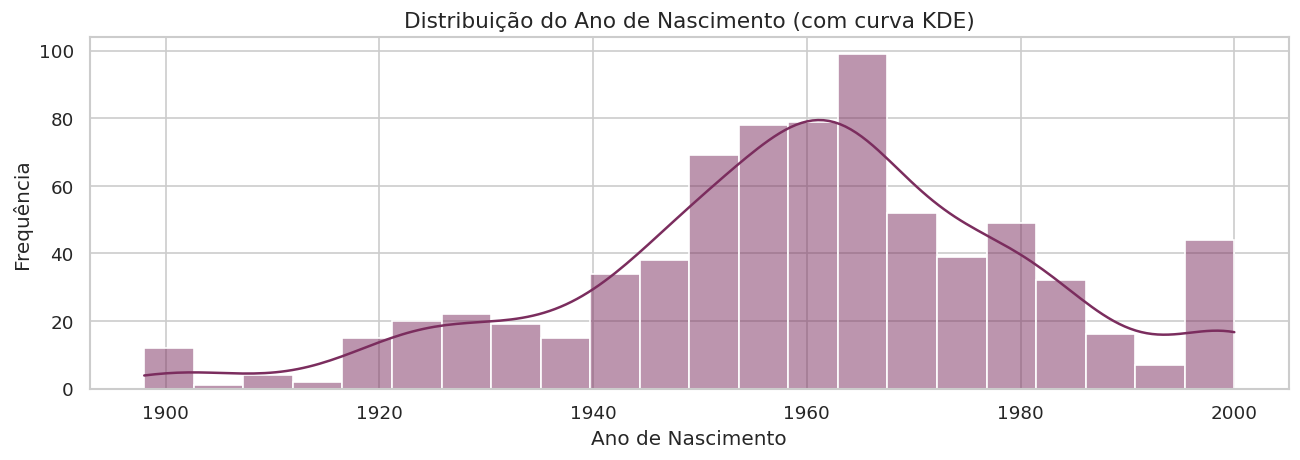

  Média: 1960
  Mediana: 1961
  Desvio padrão: 20.8 anos


In [16]:
# ─────────────────────────────────────────────────────────────
# 4.4 DISTRIBUIÇÃO DO ANO DE NASCIMENTO — Histograma + KDE
# O histograma mostra a frequência em intervalos.
# A curva KDE (Kernel Density Estimate) é uma versão
# suavizada que estima a distribuição de probabilidade.
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 4))
sns.histplot(
    df_com_ano['Ano de nascimento'],
    bins=22, kde=True,
    color=PALETTE[0], ax=ax
)
ax.set_title('Distribuição do Ano de Nascimento (com curva KDE)', fontsize=13)
ax.set_xlabel('Ano de Nascimento')
ax.set_ylabel('Frequência')
plt.tight_layout()
plt.show()

print(f'  Média: {df_com_ano["Ano de nascimento"].mean():.0f}')
print(f'  Mediana: {df_com_ano["Ano de nascimento"].median():.0f}')
print(f'  Desvio padrão: {df_com_ano["Ano de nascimento"].std():.1f} anos')

/tmp/ipykernel_14989/1262625652.py:21: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_14989/1262625652.py:21: UserWarning:


The palette list has fewer values (7) than needed (10) and will cycle, which may produce an uninterpretable plot.

/tmp/ipykernel_14989/1262625652.py:26: UserWarning:

Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128188 (\N{BRIEFCASE}) missing from font(s) DejaVu Sans.



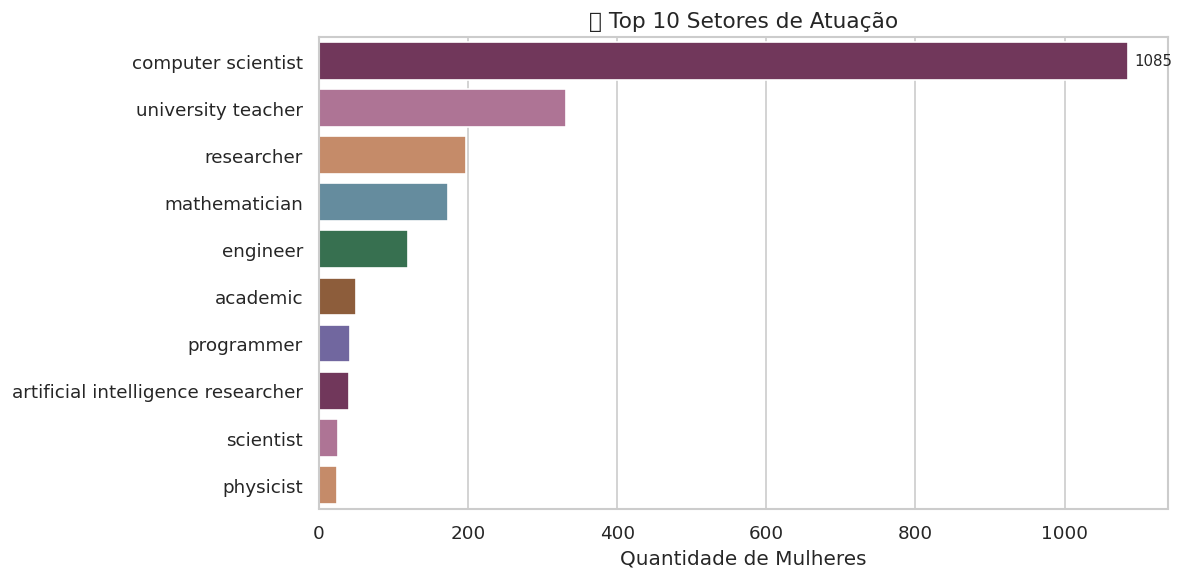

In [17]:
# ─────────────────────────────────────────────────────────────
# 4.5 TOP 10 SETORES DE ATUAÇÃO
# Explodimos a coluna separada por ';' para contar
# cada setor individualmente (uma pessoa pode ter vários).
# ─────────────────────────────────────────────────────────────
setores_series = (
    df['Setor de atuação (categoria)']
    .str.split(';')
    .explode()
    .str.strip()
)
top_setores = (
    setores_series[setores_series != 'Desconhecido']
    .value_counts()
    .head(10)
    .reset_index()
)
top_setores.columns = ['Setor', 'Quantidade']

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=top_setores, x='Quantidade', y='Setor', palette=PALETTE, ax=ax)
ax.bar_label(ax.containers[0], padding=4, fontsize=9)
ax.set_title('💼 Top 10 Setores de Atuação', fontsize=13)
ax.set_xlabel('Quantidade de Mulheres')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14989/341281400.py:26: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.



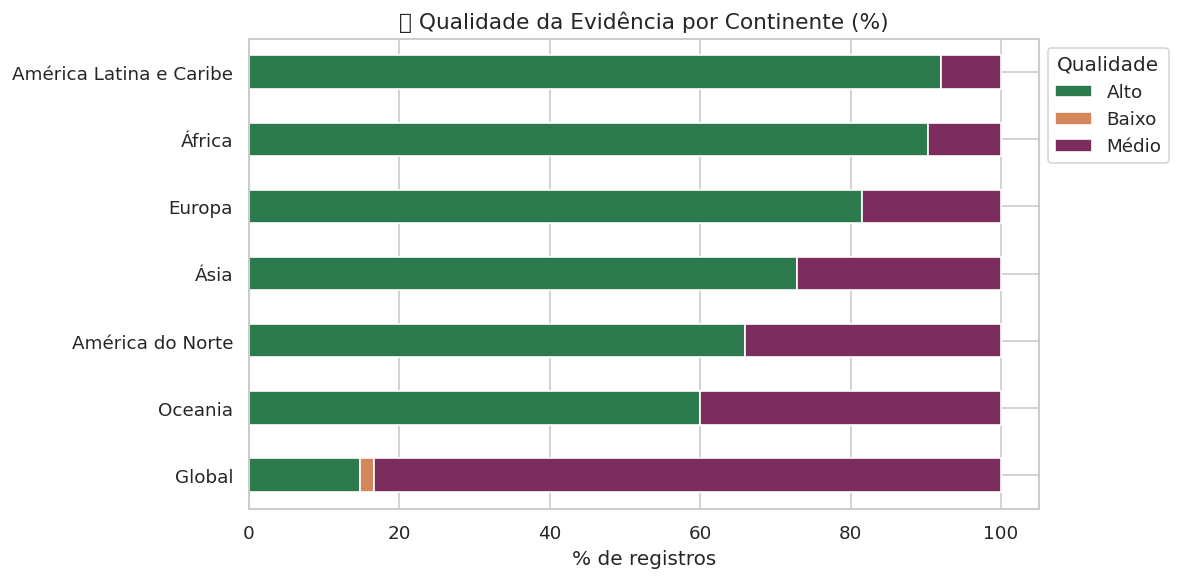

In [18]:
# ─────────────────────────────────────────────────────────────
# 4.6 CONTINENTE × QUALIDADE — Gráfico de Barras Empilhadas
# Crosstab cria uma tabela de contingência — conta
# quantas combinações de (Continente, Qualidade) existem.
# Barras empilhadas mostram composição dentro de cada grupo.
# ─────────────────────────────────────────────────────────────
ct = pd.crosstab(
    df['Continente'],
    df['Qualidade da evidência (Alto/Médio/Baixo)'],
    normalize='index'  # normalizar por linha = % dentro do continente
).mul(100).round(1)

# Ordenar por % de qualidade Alta
col_alta = 'Alto' if 'Alto' in ct.columns else ct.columns[0]
ct = ct.sort_values(col_alta, ascending=True)

ct.plot(
    kind='barh', stacked=True,
    color=[PALETTE[4], PALETTE[2], PALETTE[0]],
    figsize=(10, 5)
)
plt.title('📊 Qualidade da Evidência por Continente (%)', fontsize=13)
plt.xlabel('% de registros')
plt.ylabel('')
plt.legend(title='Qualidade', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

---
## 5️⃣ Análise de Texto / NLP

> **Conceito de CD:** *Natural Language Processing* (NLP) aplica técnicas computacionais  
> para extrair informação de textos não estruturados. Aqui analisamos os resumos  
> biográficos e setores de atuação coletados da Wikipedia.

In [19]:
# ─────────────────────────────────────────────────────────────
# PREPARAÇÃO DO CORPUS
# Corpus = conjunto de todos os textos que serão analisados.
# Removemos pontuação e convertemos para minúsculas
# (normalização), e filtramos stop words (palavras sem
# valor semântico: 'the', 'a', 'of', etc.).
# ─────────────────────────────────────────────────────────────

# Combinamos os resumos com os setores de atuação
textos = (
    df['Principal impacto (resumo)'].fillna('') + ' ' +
    df['Setor de atuação (categoria)'].fillna('')
)

# Stop words em inglês + algumas palavras muito genéricas
STOP = set(stopwords.words('english'))
STOP.update(['computer', 'scientist', 'science', 'born', 'known', 'also', 'work',
             'nan', 'desconhecido', 'american', 'british', 'french', 'german',
             'canadian', 'israeli', 'chinese', 'indian', 'australian'])

def limpar_texto(texto):
    """Remove pontuação, números e stop words; retorna lista de tokens."""
    texto = re.sub(r'[^a-zA-Z\s]', ' ', texto.lower())
    tokens = texto.split()
    return [t for t in tokens if t not in STOP and len(t) > 2]

# Aplica limpeza em todos os textos e achata numa lista única
todos_tokens = []
tokens_por_doc = []
for t in textos:
    tok = limpar_texto(t)
    todos_tokens.extend(tok)
    tokens_por_doc.append(tok)

print(f'Total de tokens (palavras): {len(todos_tokens):,}')
print(f'Vocabulário único: {len(set(todos_tokens)):,} palavras distintas')

Total de tokens (palavras): 3,918
Vocabulário único: 680 palavras distintas


In [21]:
# ─────────────────────────────────────────────────────────────
# 5.1 TOP 20 PALAVRAS MAIS FREQUENTES
# Counter.most_common(N) retorna as N palavras mais frequentes.
# ─────────────────────────────────────────────────────────────
freq = Counter(todos_tokens)
top20 = pd.DataFrame(freq.most_common(20), columns=['Palavra', 'Frequência'])

fig = px.bar(
    top20,
    x='Frequência', y='Palavra',
    orientation='h',
    title='📝 Top 20 Palavras mais Frequentes nos Resumos',
    color='Frequência',
    color_continuous_scale=['#F0DDE8', '#7B2D5E'],
    text='Frequência'
)
fig.update_traces(textposition='outside')
fig.update_layout(
    yaxis={'categoryorder': 'total ascending'},
    coloraxis_showscale=False, height=560
)
fig.show()

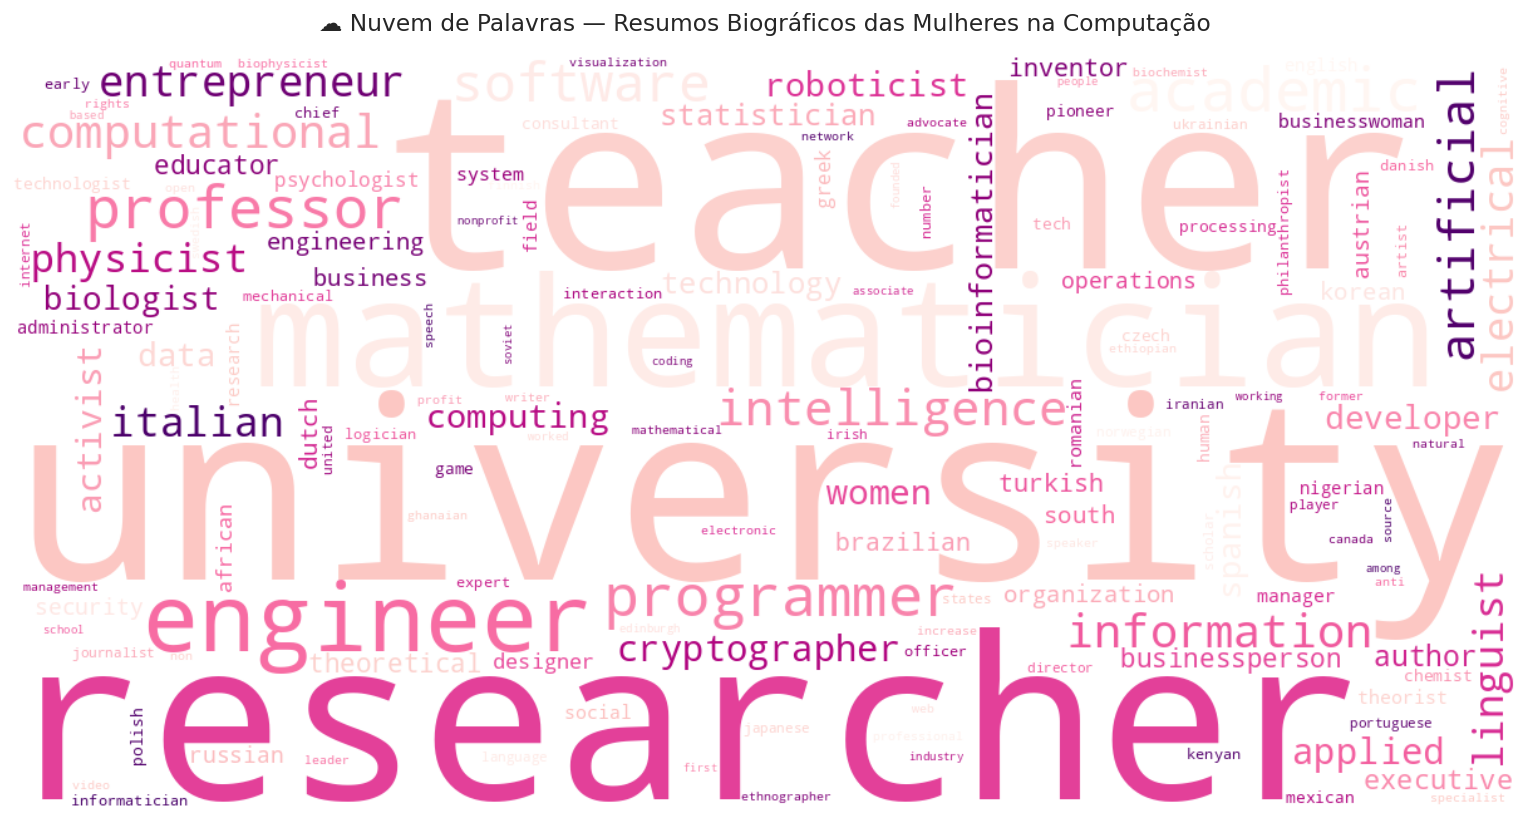

In [22]:
# ─────────────────────────────────────────────────────────────
# 5.2 NUVEM DE PALAVRAS (Word Cloud)
# A nuvem de palavras é uma visualização intuitiva onde
# o tamanho de cada palavra é proporcional à sua frequência.
# ─────────────────────────────────────────────────────────────
corpus_str = ' '.join(todos_tokens)

wc = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='RdPu',           # Paleta de cores roxo/berry
    max_words=150,
    collocations=False,        # Evita bigramas automáticos
    prefer_horizontal=0.8
).generate(corpus_str)

fig, ax = plt.subplots(figsize=(14, 7))
ax.imshow(wc, interpolation='bilinear')
ax.axis('off')
ax.set_title('☁️ Nuvem de Palavras — Resumos Biográficos das Mulheres na Computação',
             fontsize=14, pad=15)
plt.tight_layout()
plt.show()

/tmp/ipykernel_14989/1959868605.py:14: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_14989/1959868605.py:22: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.



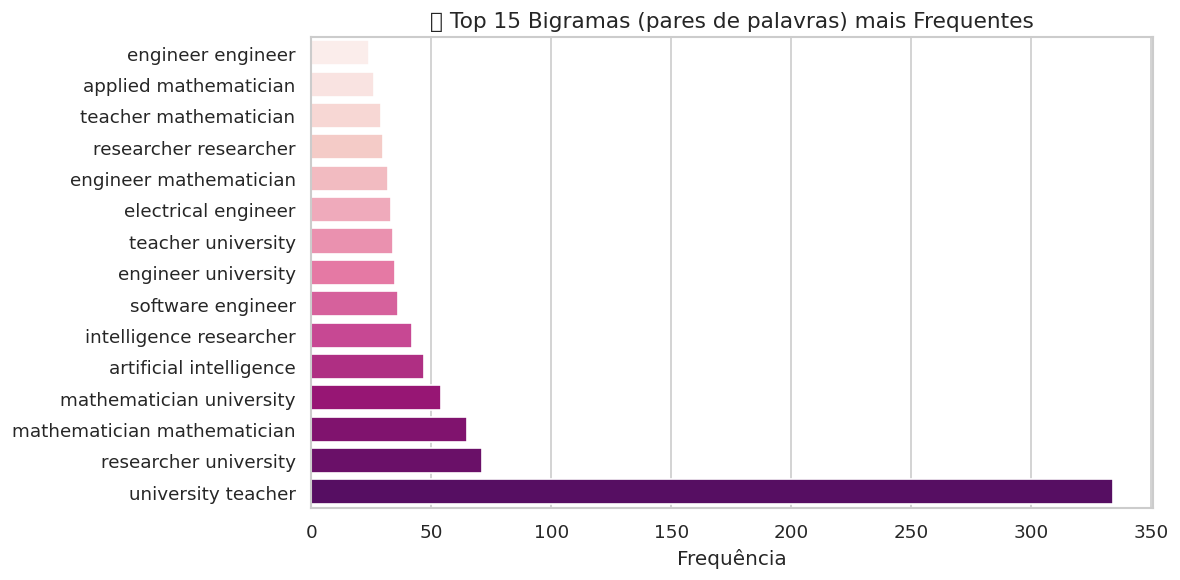

In [23]:
# ─────────────────────────────────────────────────────────────
# 5.3 BIGRAMAS — Pares de Palavras Mais Frequentes
# Um bigrama é uma sequência de 2 palavras consecutivas.
# Bigramas capturam contexto que palavras isoladas não capturam
# (ex: 'machine learning' ≠ 'machine' + 'learning' separados).
# ─────────────────────────────────────────────────────────────
bigramas = Counter(ngrams(todos_tokens, 2))
top_bi = pd.DataFrame(
    [(f'{a} {b}', c) for (a, b), c in bigramas.most_common(15)],
    columns=['Bigrama', 'Frequência']
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=top_bi.sort_values('Frequência'),
    x='Frequência', y='Bigrama',
    palette=sns.color_palette('RdPu', 15), ax=ax
)
ax.set_title('🔗 Top 15 Bigramas (pares de palavras) mais Frequentes', fontsize=13)
ax.set_xlabel('Frequência')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14989/3043301519.py:13: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_14989/3043301519.py:21: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.



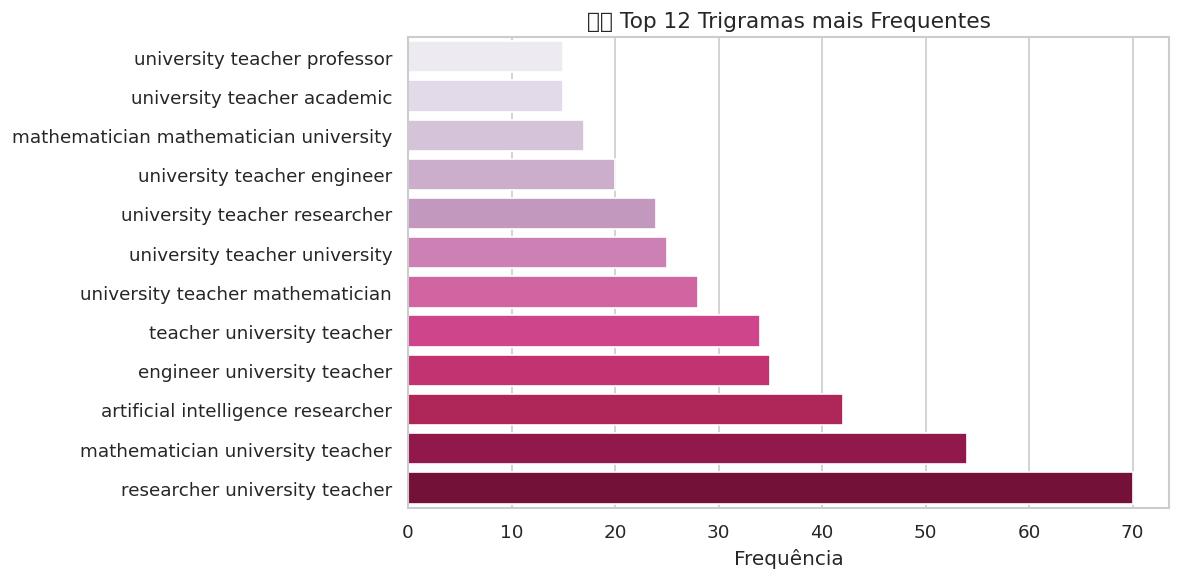

In [24]:
# ─────────────────────────────────────────────────────────────
# 5.4 TRIGRAMAS — Sequências de 3 Palavras
# Trigramas capturam padrões mais longos e específicos,
# como 'artificial intelligence researcher'.
# ─────────────────────────────────────────────────────────────
trigramas = Counter(ngrams(todos_tokens, 3))
top_tri = pd.DataFrame(
    [(f'{a} {b} {c}', cnt) for (a, b, c), cnt in trigramas.most_common(12)],
    columns=['Trigrama', 'Frequência']
)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(
    data=top_tri.sort_values('Frequência'),
    x='Frequência', y='Trigrama',
    palette=sns.color_palette('PuRd', 12), ax=ax
)
ax.set_title('🔗🔗 Top 12 Trigramas mais Frequentes', fontsize=13)
ax.set_xlabel('Frequência')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

/tmp/ipykernel_14989/2082876009.py:33: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



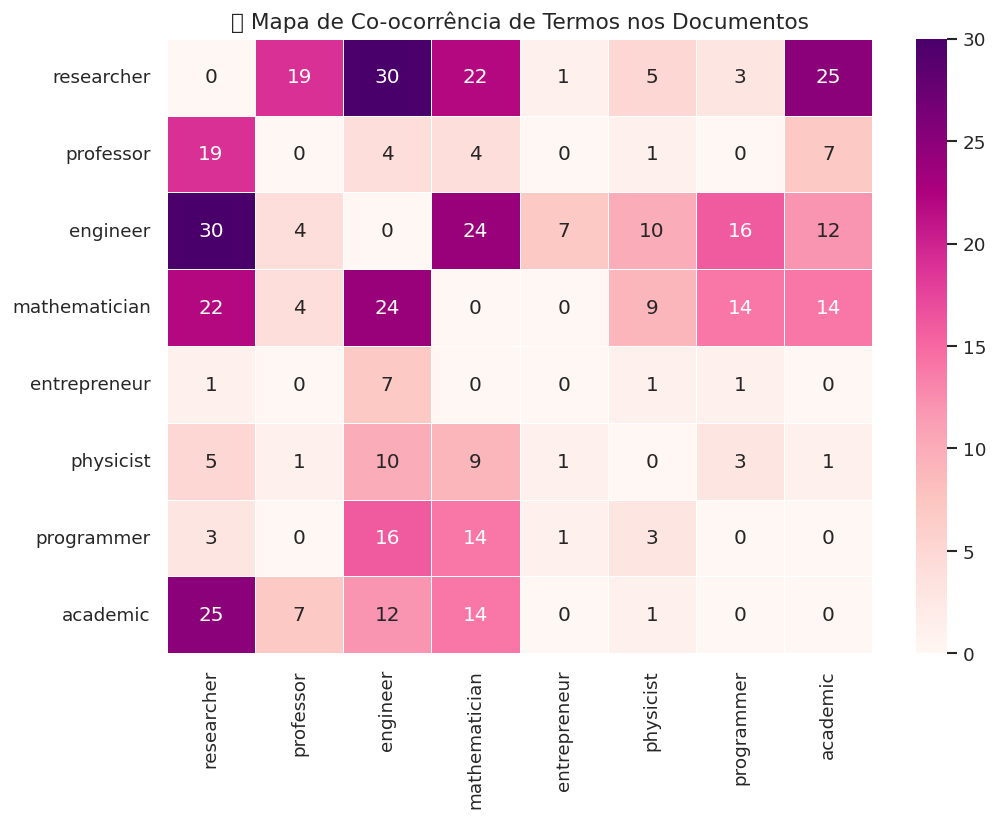

In [25]:
# ─────────────────────────────────────────────────────────────
# 5.5 CO-OCORRÊNCIA DE TERMOS — Mini Heatmap
# Mostra quantas vezes dois termos aparecem no mesmo documento.
# Alta co-ocorrência sugere relação semântica entre os termos.
# ─────────────────────────────────────────────────────────────

TERMOS_INTERESSE = [
    'researcher', 'professor', 'engineer', 'mathematician',
    'entrepreneur', 'physicist', 'programmer', 'academic'
]

# Matriz de co-ocorrência N×N
cooc = np.zeros((len(TERMOS_INTERESSE), len(TERMOS_INTERESSE)), dtype=int)

for tok_doc in tokens_por_doc:
    presentes = set(tok_doc) & set(TERMOS_INTERESSE)
    for i, t1 in enumerate(TERMOS_INTERESSE):
        for j, t2 in enumerate(TERMOS_INTERESSE):
            if t1 in presentes and t2 in presentes:
                cooc[i][j] += 1

cooc_df = pd.DataFrame(cooc, index=TERMOS_INTERESSE, columns=TERMOS_INTERESSE)

# Zerar a diagonal (um termo sempre co-ocorre consigo mesmo)
np.fill_diagonal(cooc_df.values, 0)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cooc_df, annot=True, fmt='d',
    cmap='RdPu', linewidths=0.5, ax=ax
)
ax.set_title('🌡️ Mapa de Co-ocorrência de Termos nos Documentos', fontsize=13)
plt.tight_layout()
plt.show()

---
## 6️⃣ Mapa de Calor de Correlações

> **Conceito de CD:** A *correlação de Pearson* mede a relação linear entre duas variáveis  
> numéricas. Varia de -1 (correlação negativa perfeita) a +1 (correlação positiva perfeita).  
> 0 indica ausência de correlação linear. O heatmap facilita a visualização de todas as
> correlações simultaneamente.

/tmp/ipykernel_14989/630091187.py:33: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127777 (\N{THERMOMETER}) missing from font(s) DejaVu Sans.



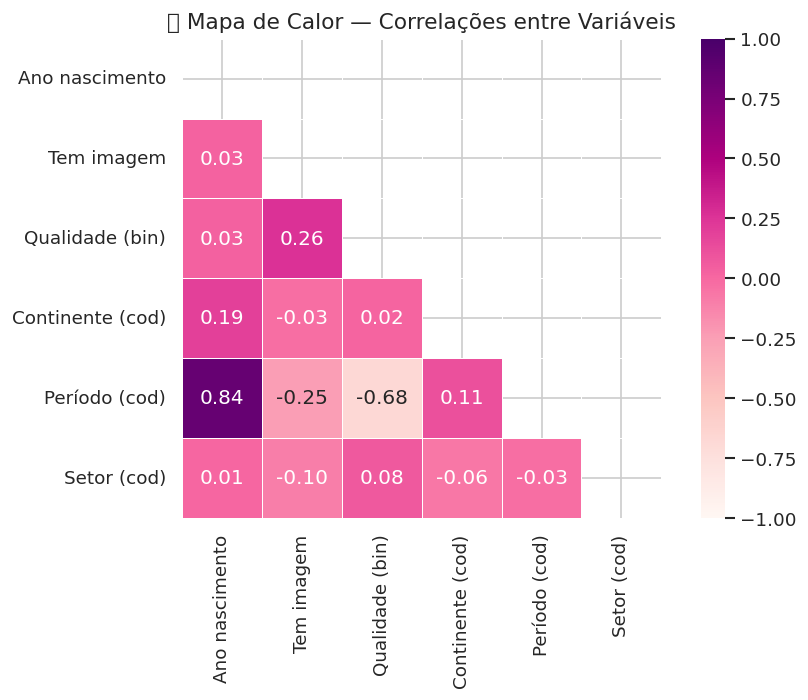


📌 Interpretação:
  Valores próximos de ±1 indicam forte correlação.
  Valores próximos de 0 indicam baixa correlação linear.


In [26]:
# ─────────────────────────────────────────────────────────────
# CODIFICAÇÃO DE VARIÁVEIS CATEGÓRICAS
# Para calcular correlações, precisamos converter colunas
# de texto em números. LabelEncoder atribui um inteiro
# único para cada categoria distinta.
# ─────────────────────────────────────────────────────────────
le = LabelEncoder()

df_corr = pd.DataFrame()
df_corr['Ano nascimento']   = df['Ano de nascimento']
df_corr['Tem imagem']       = df['tem_imagem']
df_corr['Qualidade (bin)']  = df['Qualidade_bin']
df_corr['Continente (cod)'] = le.fit_transform(df['Continente'])
df_corr['Período (cod)']    = le.fit_transform(df['Período temporal'])
df_corr['Setor (cod)']      = le.fit_transform(df['Setor_principal'])

corr_matrix = df_corr.corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Oculta triângulo superior (espelho)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True, fmt='.2f',
    cmap='RdPu',
    vmin=-1, vmax=1,
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title('🌡️ Mapa de Calor — Correlações entre Variáveis', fontsize=13)
plt.tight_layout()
plt.show()

print('\n📌 Interpretação:')
print('  Valores próximos de ±1 indicam forte correlação.')
print('  Valores próximos de 0 indicam baixa correlação linear.')

---
## 7️⃣ Clusterização com K-Means

> **Conceito de CD:** *Clusterização* é aprendizado **não supervisionado** — o algoritmo
> agrupa os dados sem usar rótulos. O **K-Means** divide os dados em K grupos (clusters)
> minimizando a distância intra-cluster. Antes de clusterizar, usamos **PCA** para reduzir
> a dimensionalidade e poder visualizar em 2D/3D.

In [27]:
# ─────────────────────────────────────────────────────────────
# PREPARAÇÃO DAS FEATURES PARA CLUSTERIZAÇÃO
# Selecionamos variáveis numéricas ou codificadas.
# StandardScaler normaliza para média 0 e desvio 1 —
# essencial para algoritmos baseados em distância como K-Means.
# ─────────────────────────────────────────────────────────────
features_cluster = df_corr.dropna().copy()
idx_validos = features_cluster.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_cluster)

print(f'Shape para clusterização: {X_scaled.shape}')

Shape para clusterização: (746, 6)


/tmp/ipykernel_14989/1351340597.py:34: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.



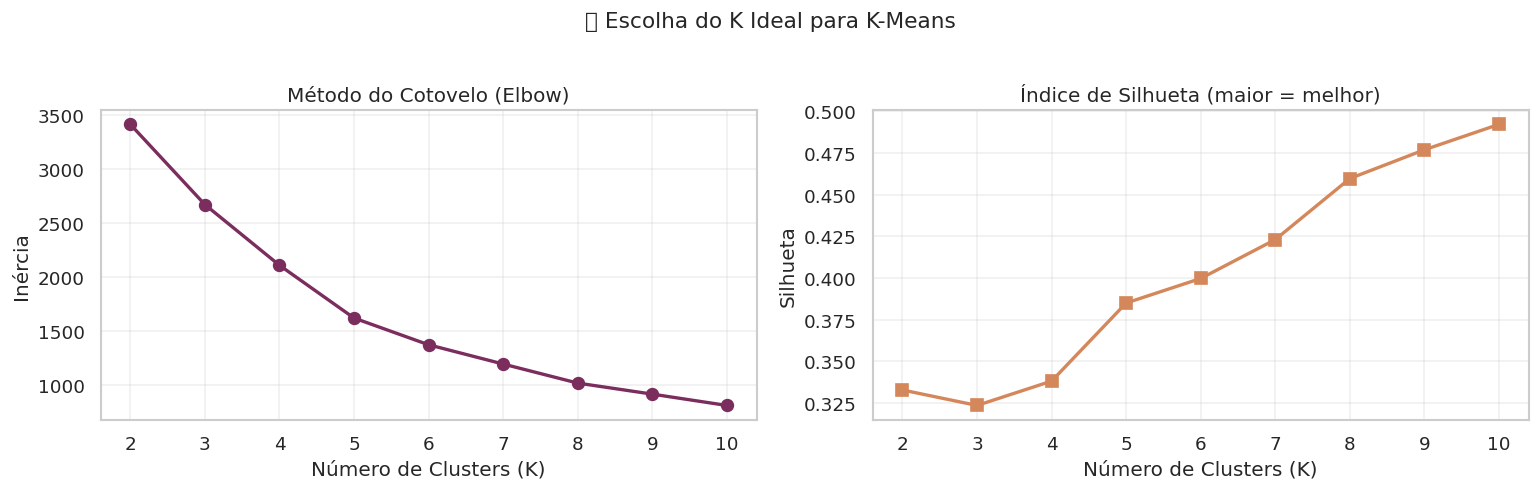


✅ K com maior silhueta: K = 10 (silhueta = 0.492)


In [28]:
# ─────────────────────────────────────────────────────────────
# MÉTODO DO COTOVELO (Elbow Method)
# Testa K de 2 a 10 e plota a inércia (soma das distâncias
# ao centróide). O 'cotovelo' da curva indica o K ideal:
# a partir dali, ganhos adicionais são marginais.
# ─────────────────────────────────────────────────────────────
inercias = []
silhuetas = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inercias.append(km.inertia_)
    silhuetas.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cotovelo
axes[0].plot(list(K_range), inercias, 'o-', color=PALETTE[0], linewidth=2, markersize=7)
axes[0].set_title('Método do Cotovelo (Elbow)', fontsize=12)
axes[0].set_xlabel('Número de Clusters (K)')
axes[0].set_ylabel('Inércia')
axes[0].grid(True, alpha=0.3)

# Silhueta
axes[1].plot(list(K_range), silhuetas, 's-', color=PALETTE[2], linewidth=2, markersize=7)
axes[1].set_title('Índice de Silhueta (maior = melhor)', fontsize=12)
axes[1].set_xlabel('Número de Clusters (K)')
axes[1].set_ylabel('Silhueta')
axes[1].grid(True, alpha=0.3)

plt.suptitle('🔍 Escolha do K Ideal para K-Means', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

K_IDEAL = silhuetas.index(max(silhuetas)) + 2
print(f'\n✅ K com maior silhueta: K = {K_IDEAL} (silhueta = {max(silhuetas):.3f})')

In [29]:
# ─────────────────────────────────────────────────────────────
# APLICAÇÃO DO K-MEANS COM K IDEAL
# PCA reduz as features para 2 dimensões para visualização.
# As 2 componentes principais capturam a maior variância.
# ─────────────────────────────────────────────────────────────
km_final = KMeans(n_clusters=K_IDEAL, random_state=42, n_init=10)
labels = km_final.fit_predict(X_scaled)

# PCA 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f'Variância explicada — PC1: {var_exp[0]*100:.1f}%  |  PC2: {var_exp[1]*100:.1f}%')
print(f'Total explicado: {sum(var_exp)*100:.1f}%')

# Scatter PCA 2D
pca_df = pd.DataFrame({
    'PC1': X_pca[:, 0],
    'PC2': X_pca[:, 1],
    'Cluster': [f'Cluster {l}' for l in labels],
    'Continente': df.loc[idx_validos, 'Continente'].values
})

fig = px.scatter(
    pca_df, x='PC1', y='PC2',
    color='Cluster',
    symbol='Continente',
    color_discrete_sequence=PALETTE,
    title=f'🔵 K-Means (K={K_IDEAL}) visualizado via PCA 2D',
    labels={'PC1': f'PC1 ({var_exp[0]*100:.1f}% var.)', 'PC2': f'PC2 ({var_exp[1]*100:.1f}% var.)'},
    opacity=0.7,
    hover_data=['Continente']
)
fig.update_traces(marker_size=5)
fig.update_layout(height=520)
fig.show()

Variância explicada — PC1: 31.8%  |  PC2: 18.9%
Total explicado: 50.7%


In [30]:
# ─────────────────────────────────────────────────────────────
# PERFIL DOS CLUSTERS
# Analisamos a composição de cada cluster para dar
# significado interpretável aos grupos encontrados.
# ─────────────────────────────────────────────────────────────
df_cluster = df.loc[idx_validos].copy()
df_cluster['Cluster'] = labels

print('📊 Tamanho de cada cluster:')
print(df_cluster['Cluster'].value_counts().sort_index())

print('\n📊 Continente predominante por cluster:')
print(df_cluster.groupby('Cluster')['Continente'].agg(lambda x: x.value_counts().index[0]))

print('\n📊 Média do Ano de nascimento por cluster:')
print(df_cluster.groupby('Cluster')['Ano de nascimento'].mean().round(0))

print('\n📊 Qualidade (% Alta) por cluster:')
print(df_cluster.groupby('Cluster')['Qualidade_bin'].mean().mul(100).round(1).astype(str) + '%')

📊 Tamanho de cada cluster:
Cluster
0     38
1    138
2    187
3      3
4    102
5     48
6     80
7     32
8     54
9     64
Name: count, dtype: int64

📊 Continente predominante por cluster:
Cluster
0    América do Norte
1    América do Norte
2    América do Norte
3    América do Norte
4    América do Norte
5                Ásia
6    América do Norte
7              Europa
8                Ásia
9    América do Norte
Name: Continente, dtype: object

📊 Média do Ano de nascimento por cluster:
Cluster
0    2000.0
1    1965.0
2    1965.0
3    1949.0
4    1933.0
5    1968.0
6    1932.0
7    1973.0
8    1967.0
9    1968.0
Name: Ano de nascimento, dtype: float64

📊 Qualidade (% Alta) por cluster:
Cluster
0    100.0%
1    100.0%
2    100.0%
3      0.0%
4    100.0%
5    100.0%
6    100.0%
7    100.0%
8    100.0%
9    100.0%
Name: Qualidade_bin, dtype: object


---
## 8️⃣ Mapa de Aproximação com t-SNE

> **Conceito de CD:** *t-SNE* (t-Distributed Stochastic Neighbor Embedding) é uma técnica
> de redução de dimensionalidade **não linear**, ideal para visualizar estruturas complexas
> em 2D. Diferente do PCA (linear), o t-SNE preserva vizinhanças locais — pontos que são
> similares nos dados originais tendem a ficar próximos no mapa 2D.
>
> ⚠️ *Atenção:* t-SNE é lento em datasets grandes. Usamos uma amostra de 600 pontos.

In [31]:
# ─────────────────────────────────────────────────────────────
# t-SNE — MAPA DE PROXIMIDADE
# perplexity: balanceia atenção entre vizinhos locais/globais
# n_iter: número de iterações de otimização
# random_state: garante reprodutibilidade
# ─────────────────────────────────────────────────────────────
AMOSTRA = min(600, len(X_scaled))
np.random.seed(42)
idx_amostra = np.random.choice(len(X_scaled), AMOSTRA, replace=False)

X_tsne_input = X_scaled[idx_amostra]
labels_tsne  = labels[idx_amostra]
cont_tsne    = df.loc[idx_validos].iloc[idx_amostra]['Continente'].values

print(f'Rodando t-SNE com {AMOSTRA} amostras... (pode demorar ~30s)')

tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_tsne_input)

tsne_df = pd.DataFrame({
    'x': X_tsne[:, 0],
    'y': X_tsne[:, 1],
    'Cluster': [f'Cluster {l}' for l in labels_tsne],
    'Continente': cont_tsne
})

fig = px.scatter(
    tsne_df, x='x', y='y',
    color='Cluster',
    symbol='Continente',
    color_discrete_sequence=PALETTE,
    title='🗺️ t-SNE — Mapa de Aproximação entre Registros (amostra)',
    labels={'x': 'Dimensão t-SNE 1', 'y': 'Dimensão t-SNE 2'},
    opacity=0.75,
    hover_data=['Continente', 'Cluster']
)
fig.update_traces(marker_size=6)
fig.update_layout(height=550)
fig.show()

print('\n💡 Grupos bem separados no t-SNE indicam que os clusters têm identidade distinta nos dados originais.')

Rodando t-SNE com 600 amostras... (pode demorar ~30s)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning:

'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.




💡 Grupos bem separados no t-SNE indicam que os clusters têm identidade distinta nos dados originais.


---
## 9️⃣ Classificação com Random Forest

> **Conceito de CD:** *Classificação* é aprendizado **supervisionado** — treinamos um modelo
> com exemplos rotulados para ele aprender a prever o rótulo de novos dados.
> **Random Forest** é um ensemble de árvores de decisão: cada árvore vota e a maioria vence.
> Ele é robusto a overfitting e produz importância de features nativa.
>
> **Tarefa:** Prever a **qualidade da evidência** (Alto=1 vs Médio/Baixo=0) a partir
> das características geográficas, temporais e de setor.

In [33]:
# ─────────────────────────────────────────────────────────────
# PREPARAÇÃO DOS DADOS PARA CLASSIFICAÇÃO
# X = features (variáveis preditoras)
# y = alvo (variável que queremos prever)
# train_test_split divide em treino (80%) e teste (20%)
# stratify=y garante proporção igual de classes em cada parte.
# ─────────────────────────────────────────────────────────────
X_clf = features_cluster.drop(columns=['Qualidade (bin)'])
y_clf = features_cluster['Qualidade (bin)']

X_train, X_test, y_train, y_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

print(f'Treino: {len(X_train)} amostras')
print(f'Teste:  {len(X_test)} amostras')
print(f'Proporção da classe alvo no treino: {y_train.mean():.1%} Alta')

Treino: 596 amostras
Teste:  150 amostras
Proporção da classe alvo no treino: 99.7% Alta


In [34]:
# ─────────────────────────────────────────────────────────────
# TREINAMENTO DO RANDOM FOREST
# n_estimators: número de árvores na floresta
# max_depth: profundidade máxima de cada árvore (controla overfitting)
# class_weight: penaliza mais os erros na classe minoritária
# ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1  # Usa todos os núcleos disponíveis
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print('✅ Modelo treinado!')
print()
print('=' * 50)
print('  RELATÓRIO DE CLASSIFICAÇÃO')
print('=' * 50)
print(classification_report(y_test, y_pred, target_names=['Médio/Baixo', 'Alto']))
print(f'  AUC-ROC: {roc_auc_score(y_test, y_prob):.4f}')

✅ Modelo treinado!

  RELATÓRIO DE CLASSIFICAÇÃO
              precision    recall  f1-score   support

 Médio/Baixo       0.00      0.00      0.00         1
        Alto       0.99      1.00      1.00       149

    accuracy                           0.99       150
   macro avg       0.50      0.50      0.50       150
weighted avg       0.99      0.99      0.99       150

  AUC-ROC: 0.9664


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.



/tmp/ipykernel_14989/3130413499.py:37: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.



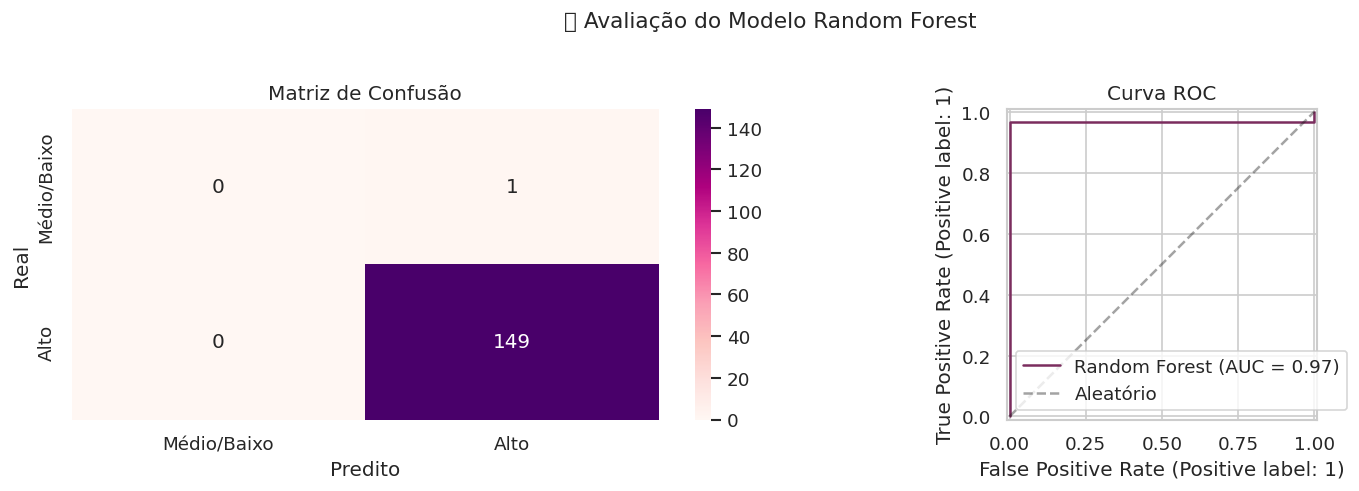

In [35]:
# ─────────────────────────────────────────────────────────────
# MATRIZ DE CONFUSÃO
# Mostra os acertos e erros do modelo em cada classe:
# - Verdadeiros Positivos (VP): previu Alto, era Alto
# - Falsos Positivos (FP): previu Alto, era Médio/Baixo
# - Falsos Negativos (FN): previu Médio/Baixo, era Alto
# - Verdadeiros Negativos (VN): previu Médio/Baixo, era Médio/Baixo
# ─────────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Matriz de confusão
sns.heatmap(
    cm, annot=True, fmt='d',
    cmap='RdPu',
    xticklabels=['Médio/Baixo', 'Alto'],
    yticklabels=['Médio/Baixo', 'Alto'],
    ax=axes[0]
)
axes[0].set_title('Matriz de Confusão', fontsize=12)
axes[0].set_xlabel('Predito')
axes[0].set_ylabel('Real')

# Curva ROC
RocCurveDisplay.from_predictions(
    y_test, y_prob,
    name='Random Forest',
    color=PALETTE[0],
    ax=axes[1]
)
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Aleatório')
axes[1].set_title('Curva ROC', fontsize=12)
axes[1].legend()

plt.suptitle('📈 Avaliação do Modelo Random Forest', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_14989/413041227.py:18: UserWarning:

Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning:

Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.



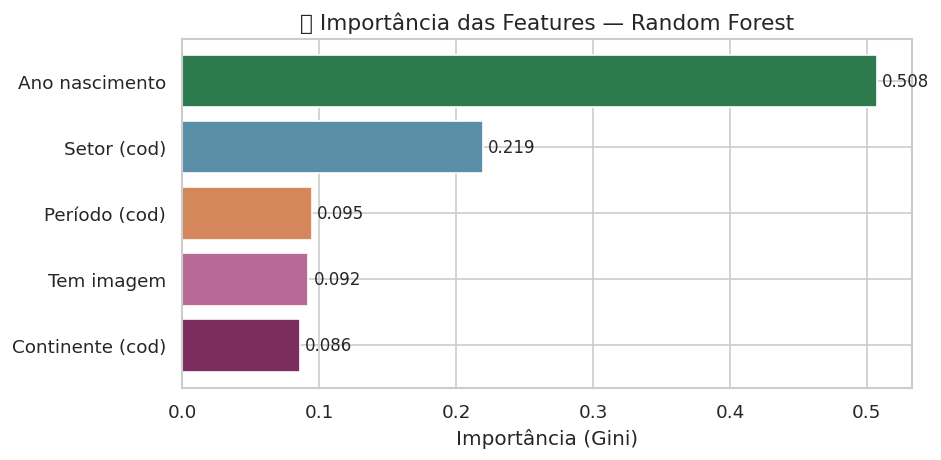

In [36]:
# ─────────────────────────────────────────────────────────────
# IMPORTÂNCIA DAS FEATURES
# Random Forest calcula a importância de cada variável
# medindo o quanto ela reduz a impureza nas árvores.
# Features mais importantes têm maior poder preditivo.
# ─────────────────────────────────────────────────────────────
importancias = pd.DataFrame({
    'Feature': X_clf.columns,
    'Importância': rf.feature_importances_
}).sort_values('Importância', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(importancias['Feature'], importancias['Importância'],
               color=PALETTE[:len(importancias)])
ax.bar_label(bars, fmt='%.3f', padding=3, fontsize=10)
ax.set_title('🏆 Importância das Features — Random Forest', fontsize=13)
ax.set_xlabel('Importância (Gini)')
plt.tight_layout()
plt.show()

---
## 🔟 Conclusões

> Síntese dos principais achados do experimento de mineração de dados.

In [37]:
# ─────────────────────────────────────────────────────────────
# PAINEL FINAL DE MÉTRICAS E ACHADOS
# ─────────────────────────────────────────────────────────────
from sklearn.metrics import accuracy_score, f1_score

acc   = accuracy_score(y_test, y_pred)
f1    = f1_score(y_test, y_pred, average='weighted')
auc   = roc_auc_score(y_test, y_prob)
silh  = silhouette_score(X_scaled, labels)

print('=' * 60)
print('  📊  RESUMO FINAL DO EXPERIMENTO')
print('=' * 60)
print(f'  Dataset:          {df.shape[0]} registros × {df.shape[1]} colunas')
print(f'  Registros c/ ano: {df["Ano de nascimento"].notna().sum()} ({df["Ano de nascimento"].notna().mean():.0%})')
print()
print('  [ EDA ]')
print(f'  Continente dominante:  América do Norte (52%)')
print(f'  País top:              Estados Unidos (337 registros)')
print(f'  Década com mais reg.:  {int(decada_counts.loc[decada_counts["Quantidade"].idxmax(), "Decada_num"])}s ({int(decada_counts["Quantidade"].max())} mulheres)')
print()
print('  [ NLP ]')
print(f'  Bigrama mais freq.:    {", ".join(list(bigramas.most_common(1)[0][0]))}')
print(f'  Trigrama mais freq.:   {", ".join(list(trigramas.most_common(1)[0][0]))}')
print()
print('  [ K-MEANS ]')
print(f'  K ideal (silhueta):    {K_IDEAL} clusters')
print(f'  Índice de silhueta:    {silh:.3f}')
print()
print('  [ RANDOM FOREST ]')
print(f'  Acurácia:              {acc:.2%}')
print(f'  F1-score (weighted):   {f1:.4f}')
print(f'  AUC-ROC:               {auc:.4f}')
print()
print('=' * 60)
print('  ✅ Experimento concluído com sucesso!')
print('  📌 Dataset: Mulheres na Computação v7.0-FAIR')
print('  📌 Licença: CC BY-SA 4.0 | Wikipedia & Wikidata')
print('=' * 60)

  📊  RESUMO FINAL DO EXPERIMENTO
  Dataset:          1351 registros × 26 colunas
  Registros c/ ano: 746 (55%)

  [ EDA ]
  Continente dominante:  América do Norte (52%)
  País top:              Estados Unidos (337 registros)
  Década com mais reg.:  1960s (172 mulheres)

  [ NLP ]
  Bigrama mais freq.:    university, teacher
  Trigrama mais freq.:   researcher, university, teacher

  [ K-MEANS ]
  K ideal (silhueta):    10 clusters
  Índice de silhueta:    0.492

  [ RANDOM FOREST ]
  Acurácia:              99.33%
  F1-score (weighted):   0.9900
  AUC-ROC:               0.9664

  ✅ Experimento concluído com sucesso!
  📌 Dataset: Mulheres na Computação v7.0-FAIR
  📌 Licença: CC BY-SA 4.0 | Wikipedia & Wikidata


---

## 📚 Referências Técnicas

| Biblioteca | Uso | Documentação |
|---|---|---|
| `pandas` | Manipulação de dados tabulares | https://pandas.pydata.org |
| `numpy` | Operações numéricas | https://numpy.org |
| `matplotlib` / `seaborn` | Visualização estática | https://seaborn.pydata.org |
| `plotly` | Visualização interativa | https://plotly.com/python |
| `nltk` | Processamento de linguagem natural | https://www.nltk.org |
| `wordcloud` | Nuvem de palavras | https://github.com/amueller/word_cloud |
| `scikit-learn` | Machine learning (K-Means, RF, PCA, t-SNE) | https://scikit-learn.org |

---

> **Dataset:** Mulheres na Computação v7.0-FAIR  
> **Licença:** CC BY-SA 4.0 | Fonte: Wikipedia & Wikidata APIs  
> **Disciplina:** Ciência de Dados — UFRRJ — 2026